In [ ]:


# Install required libraries
# Removing strict version constraints to allow compatible versions with numpy >= 2.0
# 1. Uninstall existing versions to prevent metadata conflicts
!pip uninstall -y numpy scipy mne scikit-learn

# 2. Install the synchronized compatible stack
# We use SciPy 1.12.0 as it is more stable with MNE 1.6.1 on NumPy 1.26.x
!pip install numpy==1.26.4 \
             scipy==1.12.0 \
             mne==1.6.1 \
             scikit-learn==1.3.2




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.12.0
Uninstalling scipy-1.12.0:
  Successfully uninstalled scipy-1.12.0
Found existing installation: mne 1.6.1
Uninstalling mne-1.6.1:
  Successfully uninstalled mne-1.6.1
Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached mne-1.6.1-py3-none-any.whl.metadata (13 kB)
  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2

In [ ]:
# Temporary fix for ModuleNotFoundError: No module named 'numpy.strings'
# This error occurs because the previously installed numpy (1.26.4) is
# incompatible with scipy 1.11.4 (or its internal dependencies), as scipy
# attempts to use 'numpy.strings' which is only available in numpy 2.0+.
# The ideal solution is to adjust the pip install commands in the first cell (9fHg-dqTBe7-).
# This re-installation here ensures compatible versions are used for this session.



import os
import gc
import numpy as np
import mne
from mne.preprocessing import ICA
from scipy.interpolate import interp1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# Define paths and configurations
base_folder = "/content/drive/MyDrive/eeg_datasets/"

# Generate list of 15 subjects: ['S01_ME', 'S02_ME', ..., 'S15_ME']
subjects = [f"S{str(i).zfill(2)}_ME" for i in range(1, 16)]

eeg_picks = list(range(31))
kinematic_picks = ['handPosX', 'handPosY', 'handPosZ']

movement_events = {
    'elbow_flexion': 1, 'elbow_extension': 2,
    'supination': 3, 'pronation': 4,
    'hand_close': 5, 'hand_open': 6
}

# Dictionary to store the PCC results for all 15 subjects
all_subjects_results = {}


--- Processing S01_ME ---
Loading: motorexecution_subject1_run1.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S01_ME/motorexecution_subject1_run1.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eog-r, eog-m, eog-l, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, elbowPosZ, ShoulderAdductio, ShoulderFlexionE, ShoulderRotation, Elbow, ProSupination, Wrist

/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'eeg'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 164863  =      0.000 ...   321.998 secs...
  -> Warning: Channel 'handPosX' has no valid data. Skipping this run.
Loading: motorexecution_subject1_run10.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S01_ME/motorexecution_subject1_run10.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eog-r, eog-m, eog-l, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, 

/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'eeg'}. Applying running numbers for duplicates.
  next(self.gen)


  -> Warning: Channel 'handPosX' has no valid data. Skipping this run.
Loading: motorexecution_subject1_run2.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S01_ME/motorexecution_subject1_run2.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eog-r, eog-m, eog-l, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, elbowPosZ, ShoulderAdductio, ShoulderFlexionE, S

...

  -> Warning: Channel 'handPosX' has no valid data. Skipping this run.
Loading: motorexecution_subject1_run8.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S01_ME/motorexecution_subject1_run8.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eog-r, eog-m, eog-l, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, elbowPosZ, ShoulderAdductio, ShoulderFlexionE, S

/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'eeg'}. Applying running numbers for duplicates.
  next(self.gen)


  -> Warning: Channel 'handPosX' has no valid data. Skipping this run.
Loading: motorexecution_subject1_run9.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S01_ME/motorexecution_subject1_run9.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eeg, eog-r, eog-m, eog-l, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, elbowPosZ, ShoulderAdductio, ShoulderFlexionE, S

/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'eeg'}. Applying running numbers for duplicates.
  next(self.gen)


  -> Warning: Channel 'handPosX' has no valid data. Skipping this run.
S01_ME Results -> X: -0.167, Y: 0.726, Z: 0.776

--- Processing S02_ME ---
Loading: motorexecution_subject2_run1.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S02_ME/motorexecution_subject2_run1.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
F3, F1, Fz, F2, F4, FFC5h, FFC3h, FFC1h, FFC2h, FFC4h, FFC6h, FC5, FC3, FC1, FCz, FC2, FC4, FC6, FTT7h, FCC5h, FCC3h, FCC1h, FCC2h, FCC4h, FCC6h, FTT8h, C5, C3, C1, Cz, C2, C4, C6, TTP7h, CCP5h, CCP3h, CCP1h, CCP2h, CCP4h, CCP6h, TTP8h, CP5, CP3, CP1, CPz, CP2, CP4, CP6, CPP5h, CPP3h, CPP1h, CPP2h, CPP4h, CPP6h, P3, P1, Pz, P2, P4, PPO1h, PPO2h, eog-l, eog-m, eog-r, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll

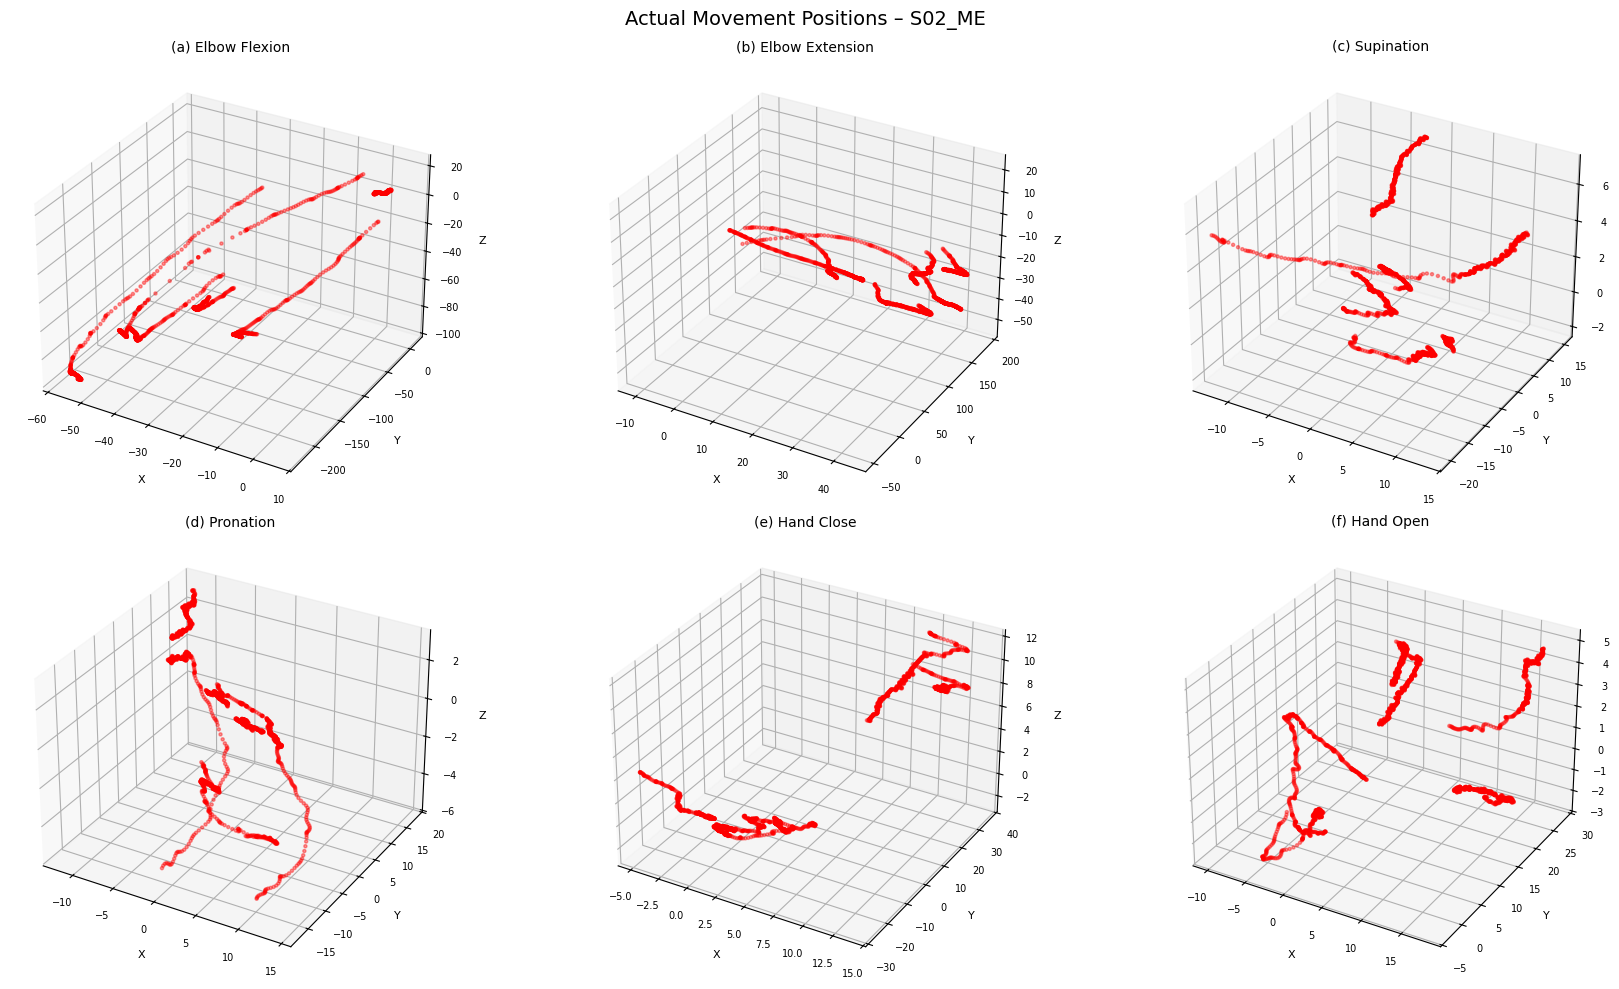

S02_ME Results -> X: 0.645, Y: 0.656, Z: 0.355

--- Processing S03_ME ---
Loading: motorexecution_subject3_run1.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S03_ME/motorexecution_subject3_run1.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
F3, F1, Fz, F2, F4, FFC5h, FFC3h, FFC1h, FFC2h, FFC4h, FFC6h, FC5, FC3, FC1, FCz, FC2, FC4, FC6, FTT7h, FCC5h, FCC3h, FCC1h, FCC2h, FCC4h, FCC6h, FTT8h, C5, C3, C1, Cz, C2, C4, C6, TTP7h, CCP5h, CCP3h, CCP1h, CCP2h, CCP4h, CCP6h, TTP8h, CP5, CP3, CP1, CPz, CP2, CP4, CP6, CPP5h, CPP3h, CPP1h, CPP2h, CPP4h, CPP6h, P3, P1, Pz, P2, P4, PPO1h, PPO2h, eog-l, eog-m, eog-r, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, el

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Loading: motorexecution_subject4_run4.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S04_ME/motorexecution_subject4_run4.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
F3, F1, Fz, F2, F4, FFC5h, FFC3h, FFC1h, FFC2h, FFC4h, FFC6h, FC5, FC3, FC1, FCz, FC2, FC4, FC6, FTT7h, FCC5h, FCC3h, FCC1h, FCC2h, FCC4h, FCC6h, FTT8h, C5, C3, C1, Cz, C2, C4, C6, TTP7h, CCP5h, CCP3h, CCP1h, CCP2h, CCP4h, CCP6h, TTP8h, CP5, CP3, CP1, CPz, CP2, CP4, CP6, CPP5h, CPP3h, CPP1h, CPP2h, CPP4h, CPP6h, P3, P1, Pz, P2, P4, PPO1h, PPO2h, eog-l, eog-m, eog-r, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, elbowPosZ, ShoulderAdductio, ShoulderFlexionE, ShoulderRotation, Elbow, ProS

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Loading: motorexecution_subject6_run5.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S06_ME/motorexecution_subject6_run5.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
F3, F1, Fz, F2, F4, FFC5h, FFC3h, FFC1h, FFC2h, FFC4h, FFC6h, FC5, FC3, FC1, FCz, FC2, FC4, FC6, FTT7h, FCC5h, FCC3h, FCC1h, FCC2h, FCC4h, FCC6h, FTT8h, C5, C3, C1, Cz, C2, C4, C6, TTP7h, CCP5h, CCP3h, CCP1h, CCP2h, CCP4h, CCP6h, TTP8h, CP5, CP3, CP1, CPz, CP2, CP4, CP6, CPP5h, CPP3h, CPP1h, CPP2h, CPP4h, CPP6h, P3, P1, Pz, P2, P4, PPO1h, PPO2h, eog-l, eog-m, eog-r, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, elbowPosZ, ShoulderAdductio, ShoulderFlexionE, ShoulderRotation, Elbow, ProS

...

Loading: motorexecution_subject8_run5.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S08_ME/motorexecution_subject8_run5.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
F3, F1, Fz, F2, F4, FFC5h, FFC3h, FFC1h, FFC2h, FFC4h, FFC6h, FC5, FC3, FC1, FCz, FC2, FC4, FC6, FTT7h, FCC5h, FCC3h, FCC1h, FCC2h, FCC4h, FCC6h, FTT8h, C5, C3, C1, Cz, C2, C4, C6, TTP7h, CCP5h, CCP3h, CCP1h, CCP2h, CCP4h, CCP6h, TTP8h, CP5, CP3, CP1, CPz, CP2, CP4, CP6, CPP5h, CPP3h, CPP1h, CPP2h, CPP4h, CPP6h, P3, P1, Pz, P2, P4, PPO1h, PPO2h, eog-l, eog-m, eog-r, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, elbowPosZ, ShoulderAdductio, ShoulderFlexionE, ShoulderRotation, Elbow, ProS

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Loading: motorexecution_subject14_run5.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S14_ME/motorexecution_subject14_run5.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
F3, F1, Fz, F2, F4, FFC5h, FFC3h, FFC1h, FFC2h, FFC4h, FFC6h, FC5, FC3, FC1, FCz, FC2, FC4, FC6, FTT7h, FCC5h, FCC3h, FCC1h, FCC2h, FCC4h, FCC6h, FTT8h, C5, C3, C1, Cz, C2, C4, C6, TTP7h, CCP5h, CCP3h, CCP1h, CCP2h, CCP4h, CCP6h, TTP8h, CP5, CP3, CP1, CPz, CP2, CP4, CP6, CPP5h, CPP3h, CPP1h, CPP2h, CPP4h, CPP6h, P3, P1, Pz, P2, P4, PPO1h, PPO2h, eog-l, eog-m, eog-r, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, elbowPosZ, ShoulderAdductio, ShoulderFlexionE, ShoulderRotation, Elbow, Pr

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Loading: motorexecution_subject15_run3.gdf
Extracting EDF parameters from /content/drive/MyDrive/eeg_datasets/S15_ME/motorexecution_subject15_run3.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
F3, F1, Fz, F2, F4, FFC5h, FFC3h, FFC1h, FFC2h, FFC4h, FFC6h, FC5, FC3, FC1, FCz, FC2, FC4, FC6, FTT7h, FCC5h, FCC3h, FCC1h, FCC2h, FCC4h, FCC6h, FTT8h, C5, C3, C1, Cz, C2, C4, C6, TTP7h, CCP5h, CCP3h, CCP1h, CCP2h, CCP4h, CCP6h, TTP8h, CP5, CP3, CP1, CPz, CP2, CP4, CP6, CPP5h, CPP3h, CPP1h, CPP2h, CPP4h, CPP6h, P3, P1, Pz, P2, P4, PPO1h, PPO2h, eog-l, eog-m, eog-r, thumb_near, thumb_far, thumb_index, index_near, index_far, index_middle, middle_near, middle_far, middle_ring, ring_near, ring_far, ring_little, litte_near, litte_far, thumb_palm, wrist_bend, roll, pitch, gesture, handPosX, handPosY, handPosZ, elbowPosX, elbowPosY, elbowPosZ, ShoulderAdductio, ShoulderFlexionE, ShoulderRotation, Elbow, Pr

In [ ]:
from sklearn.linear_model import Ridge # <-- Make sure to add this import!

for subject in subjects:
    folder = os.path.join(base_folder, subject)
    if not os.path.exists(folder):
        print(f"Directory missing for {subject}, skipping...")
        continue

    print(f"\n--- Processing {subject} ---")
    files = sorted(os.listdir(folder))

    all_X_epochs = []
    all_Y_epochs = []
    all_labels = []

    # Load all 10 runs per subject
    for file in files:
        if file.endswith(".gdf"):
            path = os.path.join(folder, file)
            print(f"Loading: {file}")

            raw = mne.io.read_raw_gdf(path, preload=False)
            ch_names_to_keep = [raw.ch_names[i] for i in eeg_picks] + kinematic_picks
            raw.pick(ch_names_to_keep)
            raw.load_data()

            data = raw.get_data()
            skip_run = False

            for ch in range(data.shape[0]):
                x = data[ch]
                good = np.isfinite(x)
                if not good.all():
                    if good.sum() < 2:
                        print(f"  -> Warning: Channel '{raw.ch_names[ch]}' has no valid data. Skipping this run.")
                        skip_run = True
                        break
                    else:
                        f = interp1d(np.where(good)[0], x[good], kind="linear", fill_value="extrapolate")
                        data[ch] = f(np.arange(len(x)))

            if skip_run:
                del raw, data
                gc.collect()
                continue

            raw._data = data
            raw.filter(0.1, 40, verbose=False)
            raw.resample(256, verbose=False)

            ica = ICA(n_components=20, random_state=42, max_iter="auto")
            ica.fit(raw, picks=eeg_picks, verbose=False)
            raw = ica.apply(raw, verbose=False)

            events, _ = mne.events_from_annotations(raw, verbose=False)
            epochs = mne.Epochs(
                raw, events, event_id=movement_events,
                tmin=2, tmax=5, baseline=None, preload=True, verbose=False
            )

            X_data = epochs.get_data(picks=eeg_picks)
            Y_data = epochs.get_data(picks=kinematic_picks)

            # --- FIX 1: SHIFT WINDOW (Avoid reaction time) ---
            # 256 to 656 grabs exactly 400 samples (from 3.0s to 4.56s)
            all_X_epochs.append(X_data[:, :, 256:656])
            all_Y_epochs.append(Y_data[:, :, 256:656])
            # -------------------------------------------------
            all_labels.append(epochs.events[:, 2])

            del raw, data, epochs, X_data, Y_data
            gc.collect()

    if len(all_X_epochs) == 0:
        print(f"  -> CRITICAL: No valid runs found for {subject}. Skipping subject entirely.")
        continue

    X = np.concatenate(all_X_epochs, axis=0)
    Y = np.concatenate(all_Y_epochs, axis=0)
    labels = np.concatenate(all_labels, axis=0)


    # ── 3D TRAJECTORY PLOT (raw values, before normalization) ──────────────
    if subject == "S02_ME":
        import matplotlib.pyplot as plt
        from mpl_toolkits.mplot3d import Axes3D

        movement_names = {
            1: 'Elbow Flexion',    2: 'Elbow Extension',
            3: 'Supination',       4: 'Pronation',
            5: 'Hand Close',       6: 'Hand Open'
        }

        fig = plt.figure(figsize=(18, 10))
        fig.suptitle(f"Actual Movement Positions – {subject}", fontsize=14)

        for idx, (class_id, class_name) in enumerate(movement_names.items()):
            ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
            trial_indices = np.where(labels == class_id)[0]

            for trial_i in trial_indices:
                ax.scatter(Y[trial_i, 0, :],   # handPosX
                           Y[trial_i, 1, :],   # handPosY
                           Y[trial_i, 2, :],   # handPosZ
                           c='red', s=5, alpha=0.4)

            ax.set_title(f"({chr(97+idx)}) {class_name}", fontsize=10)
            ax.set_xlabel("X", fontsize=8)
            ax.set_ylabel("Y", fontsize=8)
            ax.set_zlabel("Z", fontsize=8)
            ax.tick_params(labelsize=7)

        plt.tight_layout()
        plt.savefig(f"actual_trajectories_{subject}.png", dpi=150, bbox_inches='tight')
        plt.show()
    # ───────────────────────────────────────────────────────────────────────



    n_trials, n_channels, n_samples = X.shape

    # --- FIX 2: GLOBAL SCALING (Preserve spatial relations) ---
    # Kinematics Global Scaling
    Y_flat = Y.transpose(0,2,1).reshape(-1, 3)
    Y_flat = MinMaxScaler(feature_range=(-1,1)).fit_transform(Y_flat)
    Y = Y_flat.reshape(n_trials, 400, 3).transpose(0,2,1)

    # EEG Global Standardization
    X_flat = X.transpose(0,2,1).reshape(-1, n_channels)
    X_flat = StandardScaler().fit_transform(X_flat)
    X = X_flat.reshape(n_trials, 400, n_channels).transpose(0,2,1)
    # ----------------------------------------------------------

    X_reshaped = X.transpose(0,2,1).reshape(-1, n_channels)
    pca = PCA(n_components=0.9)
    X_pca_flat = pca.fit_transform(X_reshaped)
    K = X_pca_flat.shape[1]
    X_pca = X_pca_flat.reshape(n_trials, n_samples, K).transpose(0,2,1)

    # Train/Test Split
    X_train_trials, X_test_trials, Y_train_trials, Y_test_trials, labels_train, labels_test = train_test_split(
        X_pca, Y, labels, test_size=0.2, random_state=42
    )

    poly = PolynomialFeatures(degree=3)

    class_models = {c: {'X': None, 'Y': None, 'Z': None} for c in range(1, 7)}

    for c in range(1, 7):
        idx_c = np.where(labels_train == c)[0]
        if len(idx_c) == 0:
            continue

        coefs_X, inters_X = [], []
        coefs_Y, inters_Y = [], []
        coefs_Z, inters_Z = [], []

        for i in idx_c:
            X_trial = X_train_trials[i].T
            Y_trial = Y_train_trials[i].T
            X_poly = poly.fit_transform(X_trial)

            # --- FIX 3: RIDGE REGRESSION (Prevent matrix explosion) ---
            mx = Ridge(alpha=10.0).fit(X_poly, Y_trial[:, 0])
            my = Ridge(alpha=10.0).fit(X_poly, Y_trial[:, 1])
            mz = Ridge(alpha=10.0).fit(X_poly, Y_trial[:, 2])
            # ----------------------------------------------------------

            coefs_X.append(mx.coef_)
            inters_X.append(mx.intercept_)
            coefs_Y.append(my.coef_)
            inters_Y.append(my.intercept_)
            coefs_Z.append(mz.coef_)
            inters_Z.append(mz.intercept_)

        def average_top_50(coef_list):
            coef_arr = np.array(coef_list)
            n_keep = max(1, coef_arr.shape[0] // 2)
            final_coef = np.zeros(coef_arr.shape[1])
            for feat_idx in range(coef_arr.shape[1]):
                vals = coef_arr[:, feat_idx]
                top_indices = np.argsort(np.abs(vals))[-n_keep:]
                final_coef[feat_idx] = np.mean(vals[top_indices])
            return final_coef

        def average_top_50_intercept(inter_list):
            vals = np.array(inter_list)
            n_keep = max(1, len(vals) // 2)
            top_indices = np.argsort(np.abs(vals))[-n_keep:]
            return np.mean(vals[top_indices])

        class CustomReg:
            def __init__(self, coef, intercept):
                self.coef = coef
                self.intercept = intercept
            def predict(self, x):
                return np.dot(x, self.coef) + self.intercept

        class_models[c]['X'] = CustomReg(average_top_50(coefs_X), average_top_50_intercept(inters_X))
        class_models[c]['Y'] = CustomReg(average_top_50(coefs_Y), average_top_50_intercept(inters_Y))
        class_models[c]['Z'] = CustomReg(average_top_50(coefs_Z), average_top_50_intercept(inters_Z))

    # --- EVALUATE ---
    Y_pred_all = []
    Y_true_all = []

    for i in range(len(X_test_trials)):
        c = labels_test[i]
        if class_models[c]['X'] is None:
            continue

        X_trial = X_test_trials[i].T
        Y_trial = Y_test_trials[i].T
        X_poly = poly.transform(X_trial)

        pred_X = class_models[c]['X'].predict(X_poly)
        pred_Y = class_models[c]['Y'].predict(X_poly)
        pred_Z = class_models[c]['Z'].predict(X_poly)

        Y_pred_all.append(np.stack([pred_X, pred_Y, pred_Z], axis=1))
        Y_true_all.append(Y_trial)

    Y_pred_flat = np.concatenate(Y_pred_all, axis=0)
    Y_true_flat = np.concatenate(Y_true_all, axis=0)

    subject_pcc = {}
    for i, name in enumerate(["X", "Y", "Z"]):
        corr, _ = pearsonr(Y_true_flat[:,i], Y_pred_flat[:,i])
        subject_pcc[name] = corr

    print(f"{subject} Results -> X: {subject_pcc['X']:.3f}, Y: {subject_pcc['Y']:.3f}, Z: {subject_pcc['Z']:.3f}")

    all_subjects_results[subject] = subject_pcc

    del X, Y, X_pca, Y_pred_all, Y_true_all
    gc.collect()

In [ ]:
# Calculate Mean PCC across all subjects
print("\n=== FINAL AVERAGE ACROSS ALL SUBJECTS ===")
mean_x = np.mean([res["X"] for res in all_subjects_results.values()])
mean_y = np.mean([res["Y"] for res in all_subjects_results.values()])
mean_z = np.mean([res["Z"] for res in all_subjects_results.values()])

print(f"Mean PCC - X: {mean_x:.3f}")
print(f"Mean PCC - Y: {mean_y:.3f}")
print(f"Mean PCC - Z: {mean_z:.3f}")


=== FINAL AVERAGE ACROSS ALL SUBJECTS ===
Mean PCC - X: 0.358
Mean PCC - Y: 0.564
Mean PCC - Z: 0.362


Re-processing S15_ME for visualization...


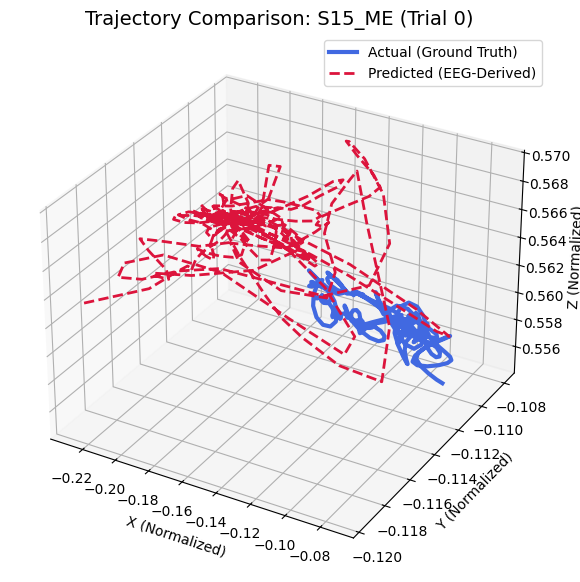

Trial 0 Correlation - X: 0.210


In [ ]:
# 1. Grab the last subject from your list
last_subject = subjects[-1]
folder = os.path.join(base_folder, last_subject)

# 2. We'll reuse the processing logic for just this one subject
# Note: We are NOT deleting variables at the end of this block
print(f"Re-processing {last_subject} for visualization...")

# (Assuming the last run's models and PCA are still in memory from the previous loop)
# If the loop finished successfully, 'class_models' and 'poly' are already set for the last subject.

# We just need to ensure Y_true_all and Y_pred_all are populated for the plot
Y_pred_all = []
Y_true_all = []

for i in range(len(X_test_trials)):
    c = labels_test[i]
    if class_models[c]['X'] is None:
        continue

    X_trial = X_test_trials[i].T
    Y_trial = Y_test_trials[i].T
    X_poly = poly.transform(X_trial)

    pred_X = class_models[c]['X'].predict(X_poly)
    pred_Y = class_models[c]['Y'].predict(X_poly)
    pred_Z = class_models[c]['Z'].predict(X_poly)

    Y_pred_all.append(np.stack([pred_X, pred_Y, pred_Z], axis=1))
    Y_true_all.append(Y_trial)

# 3. Now we plot the comparison
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

trial_idx = 0 # Change this to see different trials (0, 1, 2...)
actual_traj = Y_true_all[trial_idx]
predicted_traj = Y_pred_all[trial_idx]

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot Actual
ax.plot(actual_traj[:, 0], actual_traj[:, 1], actual_traj[:, 2],
        label='Actual (Ground Truth)', color='royalblue', linewidth=3)

# Plot Predicted
ax.plot(predicted_traj[:, 0], predicted_traj[:, 1], predicted_traj[:, 2],
        label='Predicted (EEG-Derived)', color='crimson', linestyle='--', linewidth=2)

ax.set_title(f"Trajectory Comparison: {last_subject} (Trial {trial_idx})", fontsize=14)
ax.set_xlabel("X (Normalized)")
ax.set_ylabel("Y (Normalized)")
ax.set_zlabel("Z (Normalized)")
ax.legend()

plt.show()

# Verification metrics for this specific visual
from scipy.stats import pearsonr
pcc_x, _ = pearsonr(actual_traj[:,0], predicted_traj[:,0])
print(f"Trial {trial_idx} Correlation - X: {pcc_x:.3f}")